In [2]:
import pandas as pd

df = pd.read_csv('NYPD_Complaint_Data_Historic_20250418.csv')

In [3]:
import folium
from folium.plugins import HeatMap
from IPython.display import display, Markdown
import ipywidgets as widgets
from IPython.display import clear_output
from IPython.display import Image
import io
import selenium
import matplotlib.pyplot as plt

In [4]:
renamed_columns = {
    'CMPLNT_NUM': 'complaint_id',
    'CMPLNT_FR_DT': 'start_date',
    'CMPLNT_FR_TM': 'start_time',
    'CMPLNT_TO_DT': 'end_date',
    'CMPLNT_TO_TM': 'end_time',
    'ADDR_PCT_CD': 'precinct_code',
    'RPT_DT': 'report_date',
    'KY_CD': 'offense_code',
    'OFNS_DESC': 'offense_description',
    'PD_CD': 'internal_code',
    'PD_DESC': 'internal_description',
    'CRM_ATPT_CPTD_CD': 'attempt_completed',
    'LAW_CAT_CD': 'law_category',
    'BORO_NM': 'borough',
    'LOC_OF_OCCUR_DESC': 'location_detail',
    'PREM_TYP_DESC': 'premise_description',
    'JURIS_DESC': 'jurisdiction_description',
    'JURISDICTION_CODE': 'jurisdiction_code',
    'PARKS_NM': 'park_name',
    'HADEVELOPT': 'nycha_development',
    'HOUSING_PSA': 'housing_psa',
    'X_COORD_CD': 'x_coord',
    'Y_COORD_CD': 'y_coord',
    'SUSP_AGE_GROUP': 'suspect_age_group',
    'SUSP_RACE': 'suspect_race',
    'SUSP_SEX': 'suspect_sex',
    'TRANSIT_DISTRICT': 'transit_district',
    'Latitude': 'latitude',
    'Longitude': 'longitude',
    'Lat_Lon': 'lat_lon',
    'PATROL_BORO': 'patrol_borough',
    'STATION_NAME': 'station_name',
    'VIC_AGE_GROUP': 'victim_age_group',
    'VIC_RACE': 'victim_race',
    'VIC_SEX': 'victim_sex'
}
df.rename(columns=renamed_columns, inplace=True)


In [5]:
df['victim_sex'] = df['victim_sex'].apply(lambda x: x if x in ['M', 'F'] else 'Others')
df['suspect_sex'] = df['suspect_sex'].apply(lambda x: x if x in ['M', 'F'] else 'Others')

df['month'] = pd.to_datetime(df['report_date'], errors='coerce').dt.month

**WHO**
- Suspect
- Victim

In [6]:
import plotly.graph_objects as go

# Filter out rows where victim_age_group or victim_race is 'UNKNOWN'
df2 = df[df['victim_age_group'] != 'UNKNOWN']
df2= df2[df2['victim_race'] != 'UNKNOWN']


# Remove rows where 'attempt_completed' is null
df2 = df2[df2['attempt_completed'] != '(null)']



# Filter out rows where victim_age_group or victim_race is 'UNKNOWN'
df2 = df2[df2['suspect_age_group'] != 'UNKNOWN']
df2 = df2[df2['suspect_race'] != 'UNKNOWN']

# Define the list of unwanted age groups
unwanted_age_groups = ['(null)', '-2', '-971', '1013', '929', '943', '971', '957']

# Filter the dataframe
df2 = df2[~df2['victim_age_group'].isin(unwanted_age_groups)]
df2 = df2[df2['victim_race'] != '(null)']

# Sort victim_age_group in the specified order
age_group_order = reversed(['<18', '18-24', '25-44', '45-64', '65+'])
df2['victim_age_group'] = pd.Categorical(df2['victim_age_group'], categories=age_group_order, ordered=True)


# Prepare the data for the Sankey diagram
victim_labels = list(df2['victim_sex'].unique()) + list(df2['victim_race'].unique()) + list(df2['victim_age_group'].unique())
victim_label_to_index = {label: i for i, label in enumerate(victim_labels)}

# Create source and target indices
link_counts = {'source': [], 'target': [], 'value': []}

# Add links between victim_sex and victim_race
for sex in df2['victim_sex'].unique():
    for race in df2['victim_race'].unique():
        count = len(df2[(df2['victim_sex'] == sex) & (df2['victim_race'] == race)])
        if count > 0:
            link_counts['source'].append(victim_label_to_index[sex])
            link_counts['target'].append(victim_label_to_index[race])
            link_counts['value'].append(count)

# Add links between victim_race and victim_age_group
for race in df2['victim_race'].unique():
    for age_group in df2['victim_age_group'].unique():
        count = len(df2[(df2['victim_race'] == race) & (df2['victim_age_group'] == age_group)])
        if count > 0:
            link_counts['source'].append(victim_label_to_index[race])
            link_counts['target'].append(victim_label_to_index[age_group])
            link_counts['value'].append(count)

# Define colors for links (optional, can use node colors or a gradient)
link_colors = ["rgba(170, 10, 10, 0.5)" for _ in range(len(link_counts['value']))]

# Create the Sankey diagram with colors
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=victim_labels,
        color="lightgrey"  # Set node color to light grey
    ),
    link=dict(
        source=link_counts['source'],
        target=link_counts['target'],
        value=link_counts['value'],
        color=link_colors  # Link colors remain as defined
    )
)])

# Add title and display the diagram
fig.update_layout(title_text="Sankey Diagram of Victim Information (Sex, Race, Age Group)", font_size=10)
fig.show()

# Export the Sankey diagram as an HTML file
fig.write_html("sankey_diagram_victim_information.html")

In [7]:
# Define the list of unwanted age groups
unwanted_age_groups2 = ['(null)', '2019','2013',2019,2013]

# Filter the dataframe
df2 = df2[~df2['suspect_age_group'].isin(unwanted_age_groups2)]
df2 = df2[df2['victim_race'] != '(null)']


import plotly.graph_objects as go

# Prepare the data for the Sankey diagram
suspect_labels = list(df2['suspect_sex'].unique()) + list(df2['suspect_race'].unique()) + list(df2['suspect_age_group'].unique())
suspect_label_to_index = {label: i for i, label in enumerate(suspect_labels)}

# Create source and target indices
suspect_link_counts = {'source': [], 'target': [], 'value': []}

# Add links between suspect_sex and suspect_race
for sex in df2['suspect_sex'].unique():
    for race in df2['suspect_race'].unique():
        count = len(df2[(df2['suspect_sex'] == sex) & (df2['suspect_race'] == race)])
        if count > 0:
            suspect_link_counts['source'].append(suspect_label_to_index[sex])
            suspect_link_counts['target'].append(suspect_label_to_index[race])
            suspect_link_counts['value'].append(count)

# Add links between suspect_race and suspect_age_group
for race in df2['suspect_race'].unique():
    for age_group in df2['suspect_age_group'].unique():
        count = len(df2[(df2['suspect_race'] == race) & (df2['suspect_age_group'] == age_group)])
        if count > 0:
            suspect_link_counts['source'].append(suspect_label_to_index[race])
            suspect_link_counts['target'].append(suspect_label_to_index[age_group])
            suspect_link_counts['value'].append(count)

# Define colors for links (optional, can use node colors or a gradient)
suspect_link_colors = ["rgba(170, 10, 10, 0.5)" for _ in range(len(suspect_link_counts['value']))]

# Create the Sankey diagram with colors
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=suspect_labels,
        color="lightgrey"
    ),
    link=dict(
        source=suspect_link_counts['source'],
        target=suspect_link_counts['target'],
        value=suspect_link_counts['value'],
        color=suspect_link_colors
    )
)])

# Add title and display the diagram
fig.update_layout(title_text="Sankey Diagram of Suspect Information (Sex, Race, Age Group)", font_size=10)
fig.show()

# Export the Sankey diagram as an HTML file
fig.write_html("sankey_diagram_suspect_information.html")

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from ipywidgets import interact, Dropdown

# Define a function to update the plot based on the selected slicer
def update_correlation_plot(slicer):
    plt.figure(figsize=(12, 8))
    
    if slicer == 'Race':
        contingency_table = pd.crosstab(df2['suspect_race'], df2['victim_race'])
        sns.heatmap(
            contingency_table,
            annot=True,
            fmt="d",
            cmap=sns.light_palette("red", as_cmap=True),
            linewidths=0.5,
            cbar_kws={'label': 'Count'}
        )
        plt.title("Correlation Between Suspect and Victim Race")
        plt.xlabel("Victim Race")
        plt.ylabel("Suspect Race")
    elif slicer == 'Sex':
        contingency_table = pd.crosstab(df2['suspect_sex'], df2['victim_sex'])
        sns.heatmap(
            contingency_table,
            annot=True,
            fmt="d",
            cmap=sns.light_palette("red", as_cmap=True),
            linewidths=0.5,
            cbar_kws={'label': 'Count'}
        )
        plt.title("Correlation Between Suspect and Victim Sex")
        plt.xlabel("Victim Sex")
        plt.ylabel("Suspect Sex")
    elif slicer == 'Age':
        # Ensure the same order of age groups for both axes
        age_group_order = ['<18', '18-24', '25-44', '45-64', '65+']
        df2['victim_age_group'] = pd.Categorical(df2['victim_age_group'], categories=age_group_order, ordered=True)
        df2['suspect_age_group'] = pd.Categorical(df2['suspect_age_group'], categories=age_group_order, ordered=True)
        contingency_table = pd.crosstab(df2['suspect_age_group'], df2['victim_age_group'])
        sns.heatmap(
            contingency_table,
            annot=True,
            fmt="d",
            cmap=sns.light_palette("red", as_cmap=True),
            linewidths=0.5,
            cbar_kws={'label': 'Count'}
        )
        plt.title("Correlation Between Suspect and Victim Age Group")
        plt.xlabel("Victim Age Group")
        plt.ylabel("Suspect Age Group")
    
    plt.tight_layout()
    plt.show()

# Create a dropdown slicer
slicer_dropdown = Dropdown(
    options=['Race', 'Sex', 'Age'],
    value='Race',
    description='Slicer:'
)

# Use interact to link the dropdown to the update_correlation_plot function
interact(update_correlation_plot, slicer=slicer_dropdown)


interactive(children=(Dropdown(description='Slicer:', options=('Race', 'Sex', 'Age'), value='Race'), Output())…

<function __main__.update_correlation_plot(slicer)>

/var/folders/sw/khwy1x9s5r53sk652gjn3vzr0000gn/T/ipykernel_36189/3136035438.py:2: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



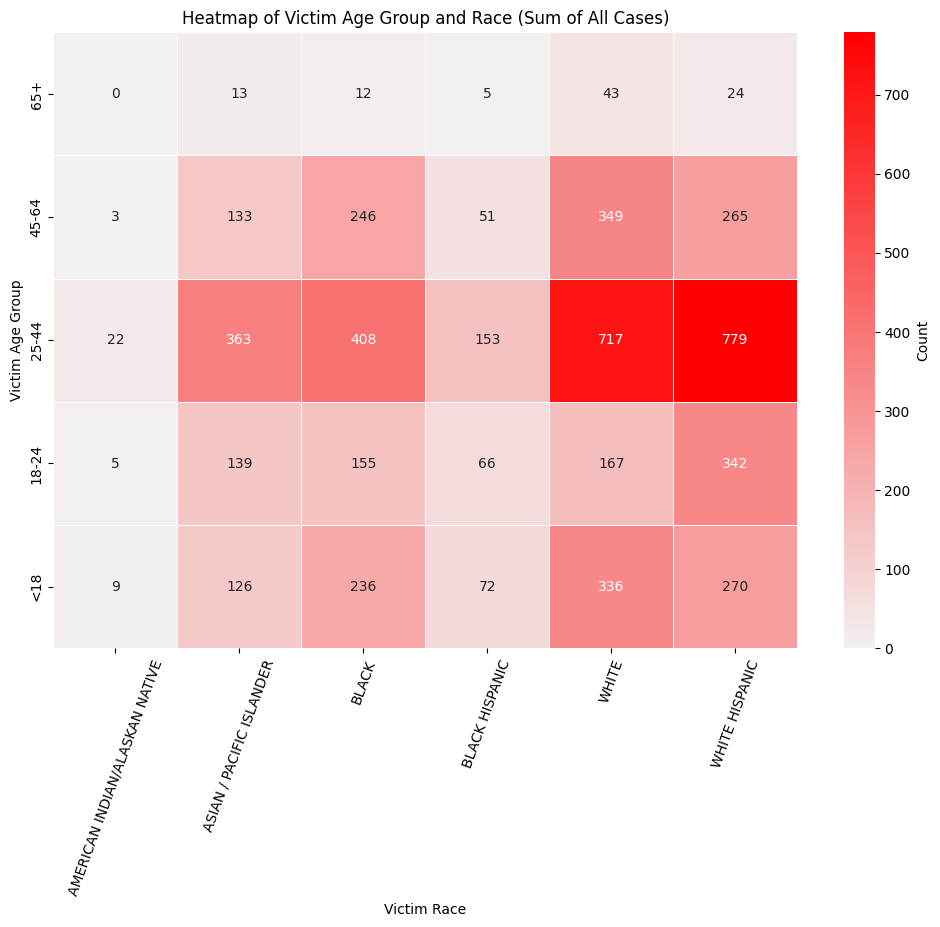

In [9]:
# Pivot the data to create a matrix of victim age group vs victim race
heatmap_data = df2.pivot_table(index='victim_age_group', columns='victim_race', aggfunc='size', fill_value=0)

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d",
    cmap=sns.light_palette("red", as_cmap=True),
    linewidths=.5,
    cbar_kws={'label': 'Count'}
)

# Add title and labels
plt.title('Heatmap of Victim Age Group and Race (Sum of All Cases)')
plt.xlabel('Victim Race')
plt.ylabel('Victim Age Group')

# Rotate the x-axis labels by 45 degrees
plt.xticks(rotation=70)

# Display the plot
plt.show()

**WHAT**

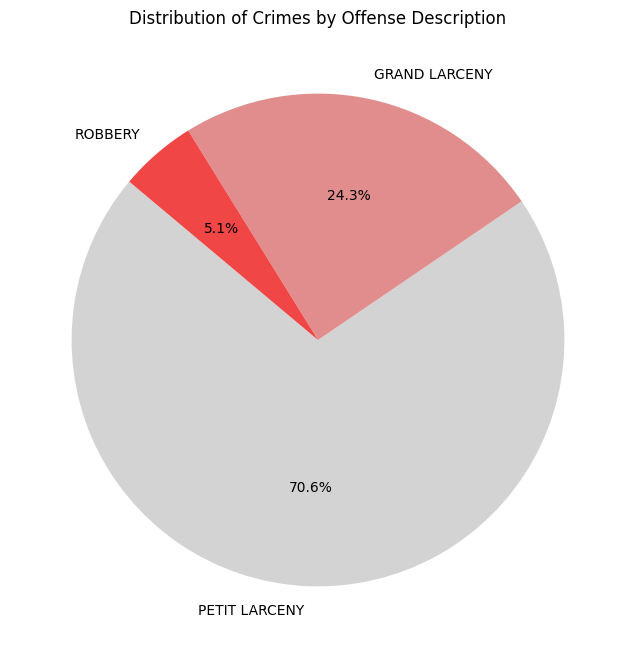

<Figure size 640x480 with 0 Axes>

In [10]:
from matplotlib.colors import LinearSegmentedColormap
import mpld3
# Calculate the counts of each offense description
offense_counts = df['offense_description'].value_counts()

# Create a custom colormap from light grey to red
cmap = LinearSegmentedColormap.from_list("grey_to_red", ["lightgrey", "red"])
colors = [cmap(i / len(offense_counts)) for i in range(len(offense_counts))]

# Create a pie chart for the distribution of crimes by offense description
plt.figure(figsize=(8, 8))
plt.pie(offense_counts.values, labels=offense_counts.index, autopct='%1.1f%%', startangle=140, colors=colors)

# Add a title
plt.title('Distribution of Crimes by Offense Description')

# Show the plot
plt.show()

# Export the pie chart as an HTML file using mpld3

html_content = mpld3.fig_to_html(plt.gcf())
with open("crime_distribution_pie_chart.html", "w") as f:
    f.write(html_content)


<Figure size 2000x1000 with 0 Axes>

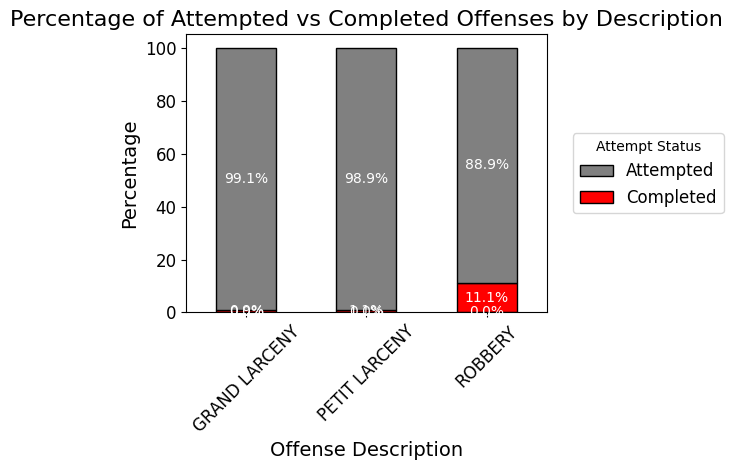

<Figure size 640x480 with 0 Axes>

In [11]:
import mpld3

# Calculate the count of attempted and completed offenses grouped by offense description
relation_data = df.groupby(['offense_description', 'attempt_completed']).size().unstack(fill_value=0)

# Calculate the percentage for each category
relation_data_percentage = relation_data.div(relation_data.sum(axis=1), axis=0) * 100

# Set the figure size
plt.figure(figsize=(20, 10))  # Increased figure size for better visibility

# Create a bar plot for percentages
ax = relation_data_percentage.plot(
    kind='bar',
    stacked=True,
    color=['grey','red'],  # Colors for attempted and completed
    edgecolor='black'
)

# Add percentages on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=10, color='white')

# Add labels and title
plt.title("Percentage of Attempted vs Completed Offenses by Description", fontsize=16)
plt.xlabel("Offense Description", fontsize=14)
plt.ylabel("Percentage", fontsize=14)

# Place the legend outside the plot
plt.legend(
    title="Attempt Status",
    labels=["Attempted", "Completed"],
    fontsize=12,
    bbox_to_anchor=(1.05, 0.5),
    loc='center left'
)

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

# Export the bar plot as an HTML file using mpld3

html_content = mpld3.fig_to_html(plt.gcf())
with open("attempt_completed_percentage.html", "w") as f:
    f.write(html_content)


**WHERE**

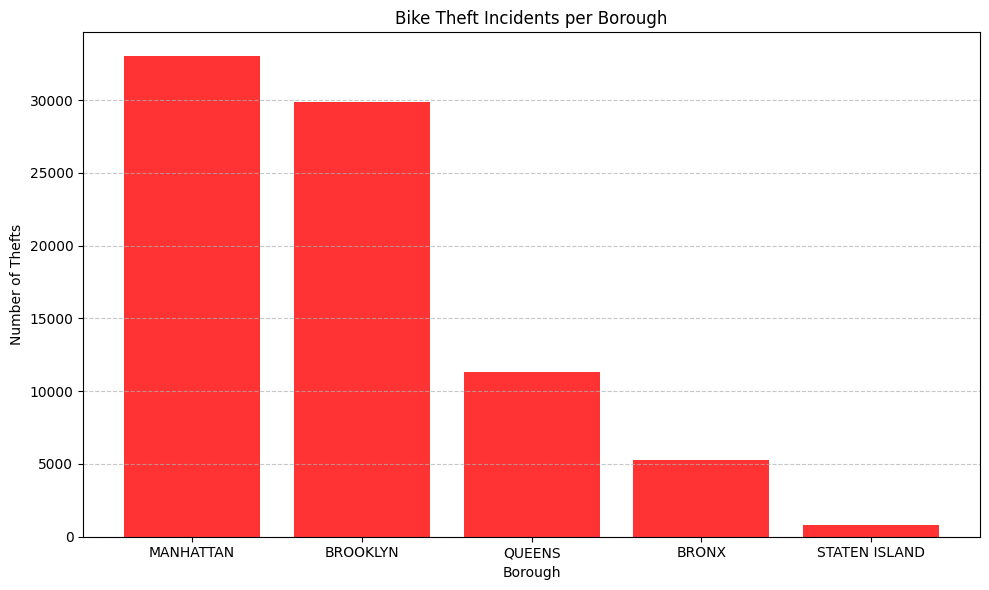

<Figure size 640x480 with 0 Axes>

In [12]:
import mpld3

# Count the number of crimes per borough
boro_counts = df[df['borough'] != '(null)']['borough'].value_counts()

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.bar(boro_counts.index, boro_counts.values, color='Red', alpha=0.8)

# Add labels and title
plt.xlabel('Borough')
plt.ylabel('Number of Thefts')
plt.title('Bike Theft Incidents per Borough')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

# Export the bar plot as an HTML file using mpld3

html_content = mpld3.fig_to_html(plt.gcf())
with open("bike_theft_incidents_per_borough.html", "w") as f:
    f.write(html_content)

**WHEN**

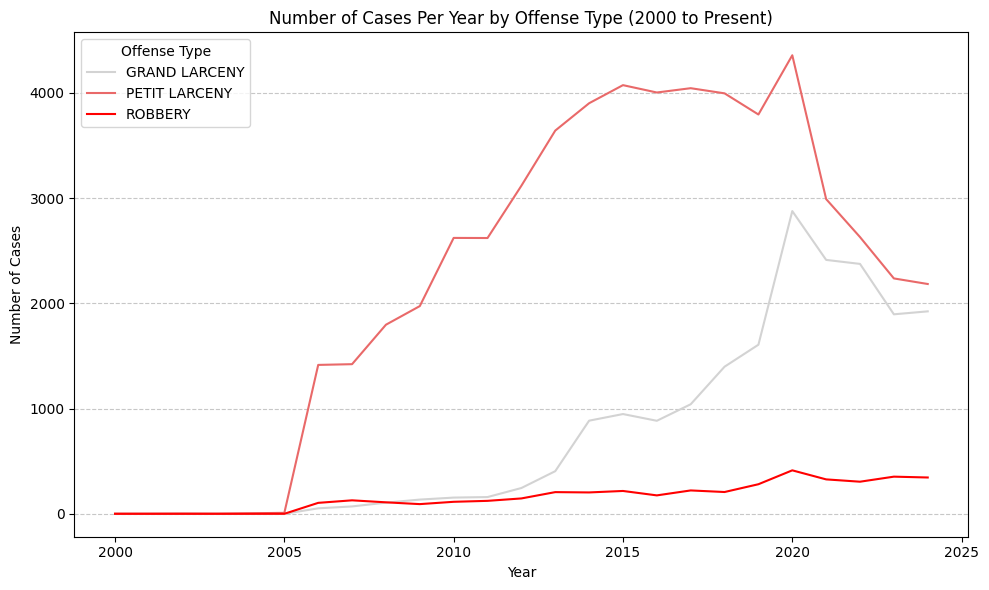

<Figure size 640x480 with 0 Axes>

In [13]:
from matplotlib.colors import LinearSegmentedColormap
import mpld3

# Ensure 'start_date' is in datetime format
df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce')

# Extract the year from 'start_date' and create a new column 'year'
df['year'] = df['start_date'].dt.year

# Filter the dataframe for cases from 2000 onwards and group by year and offense description
filtered_cases = df[df['year'] >= 2000].groupby(['year', 'offense_description']).size().unstack(fill_value=0)
# Define the gradient from light grey to red
cmap = LinearSegmentedColormap.from_list("grey_to_red", ["lightgrey", "red"])

# Generate colors for each offense type based on the number of offenses
num_offenses = len(filtered_cases.columns)
colors = [cmap(i / (num_offenses - 1)) for i in range(num_offenses)]

# Plot the line chart with gradient colors
plt.figure(figsize=(10, 6))
for offense, color in zip(filtered_cases.columns, colors):
    plt.plot(filtered_cases.index, filtered_cases[offense], marker='', linestyle='-', label=offense, color=color)

# Add labels, title, and legend
plt.xlabel('Year')
plt.ylabel('Number of Cases')
plt.title('Number of Cases Per Year by Offense Type (2000 to Present)')
plt.legend(title='Offense Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

# Export the line chart as an HTML file using mpld3

html_content = mpld3.fig_to_html(plt.gcf())
with open("cases_per_year_by_offense_type.html", "w") as f:
    f.write(html_content)

In [ ]:
from ipywidgets import interact, Dropdown
import matplotlib.pyplot as plt

# Define a function to update the bar plot based on the selected slicer
def update_bar_plot(slicer):
    plt.figure(figsize=(12, 6))
    
    if slicer == 'Month':
        data = df2['month'].value_counts().sort_index()
        plt.bar(data.index, data.values, color='red', alpha=0.7)
        plt.xlabel('Month')
        plt.ylabel('Number of Cases')
        plt.title('Number of Cases per Month')
        plt.xticks(range(1, 13))
   
    elif slicer == 'Hour of Day':
        data = df2['start_time'].str[:2].astype(int).value_counts().sort_index()
        plt.bar(data.index, data.values, color='red', alpha=0.7)
        plt.xlabel('Hour of Day')
        plt.ylabel('Number of Cases')
        plt.title('Number of Cases per Hour of Day')
        plt.xticks(range(0, 24))
    
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Create a dropdown slicer
slicer_dropdown = Dropdown(
    options=['Month', 'Hour of Day'],
    value='Month',
    description='Slicer:'
)

# Use interact to link the dropdown to the update_bar_plot function
interact(update_bar_plot, slicer=slicer_dropdown)




interactive(children=(Dropdown(description='Slicer:', options=('Month', 'Hour of Day'), value='Month'), Output…

<function __main__.update_bar_plot(slicer)>

In [15]:
# Create a new column 'YearMonth' by combining 'year' and 'month'
df['year'] = df['year'].fillna(0).astype(int)
df['YearMonth'] = df['year'].astype(str) + '-' + df['month'].astype(str).str.zfill(2)

In [16]:
df = df[df['year'] >= 2006]

In [17]:
import folium
from folium.plugins import HeatMapWithTime
from folium import Map

# Set the map size to width=1000 and height=600
heatmap_map = Map(location=[40.7128, -74.0060], zoom_start=12, width=1000, height=600)
# Group the data by YearMonth and calculate the average latitude, longitude, and count of crimes
crime_data = df.groupby('YearMonth').agg({'latitude': 'mean', 'longitude': 'mean', 'complaint_id': 'count'}).reset_index()

# Prepare data for HeatMapWithTime
heatmap_data_by_time = []
for year_month in crime_data['YearMonth'].unique():
    filtered_data = df[df['YearMonth'] == year_month]
    heatmap_data_by_time.append(
        filtered_data[['latitude', 'longitude']].dropna().values.tolist()
    )

# Add HeatMapWithTime layer
HeatMapWithTime(
    data=heatmap_data_by_time,
    index=crime_data['YearMonth'].tolist(),
    radius=10,
    auto_play=True,
    max_opacity=0.8
).add_to(heatmap_map)

# Display the map
heatmap_map

# Export the map as an HTML file
heatmap_map.save("heatmap_with_time3.html")

